In [2]:
import pandas as pd
import numpy as np
import joblib
import shap

c:\Users\OM KAPALE\urban-heat-stress-hotspot-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv(
    "../data/processed/featured_uhi_v2.csv"
)

df.head()

,Elevation,LST,Latitude,Longitude,NDBI,NDVI,Population,Green_Built_Ratio,Population_Heat_Index,Elevation_Cooling_Index
0,919,43.919170,19.970832,75.438700,0.127207,0.162286,1.562392,1.182783,0.198747,149.140825
1,488,39.060455,19.729093,75.209548,-0.272423,0.570751,1.361367,2.020910,-0.370867,278.526341
2,505,40.231127,19.788775,75.225639,0.055877,0.099371,15.386780,1.508423,0.859774,50.182390
3,757,44.884761,19.960297,75.544582,0.121404,0.196037,2.643492,1.491866,0.320931,148.400233
4,586,48.502735,19.867709,75.486062,0.133151,0.165262,31.397209,1.154459,4.180581,96.843708


In [4]:
FEATURES = ["NDVI", "NDBI", "Elevation", "Population"]
X = df[FEATURES]
y = df["LST"]

model = joblib.load("../outputs/lst_model_xgb_v3.pkl")
print("Loaded XGBoost V3 model")

Loaded XGBoost V3 model


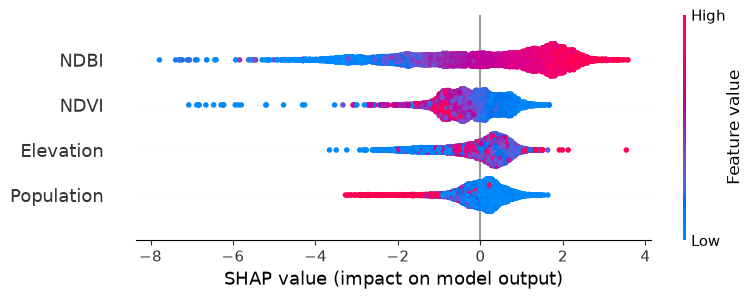

In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

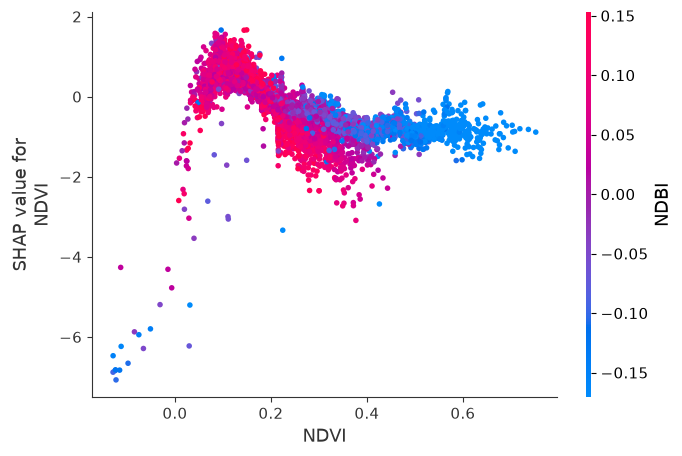

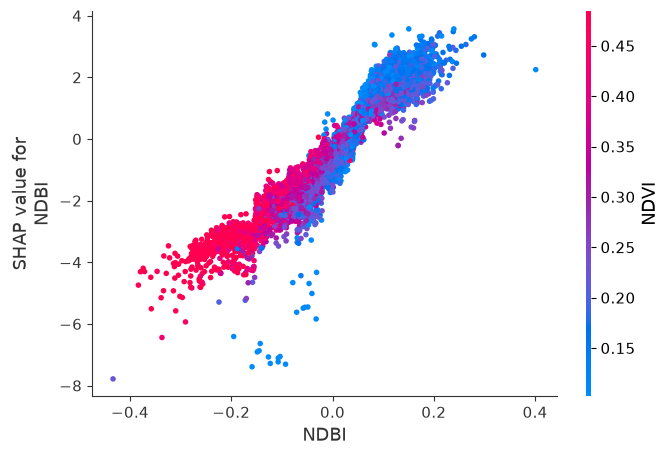

In [6]:
# Physics check:
# NDVI should slope DOWN (vegetation cools)
# NDBI should slope UP (built-up heats)
shap.dependence_plot("NDVI", shap_values, X)
shap.dependence_plot("NDBI", shap_values, X)

In [7]:
# Greening sanity gate: does adding vegetation now COOL?
baseline = model.predict(X)

green = X.copy()
green["NDVI"] = (green["NDVI"] * 1.20).clip(upper=1.0)   # +20% vegetation
delta = (model.predict(green) - baseline).mean()

print(f"Mean LST change from +20% NDVI: {delta:+.3f} C")
print("PASS (cooling)" if delta < 0 else "FAIL (still warming - tell Claude)")

Mean LST change from +20% NDVI: -0.335 C
PASS (cooling)
